In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Interpolated_Data.csv",index_col=0,parse_dates=True)

In [3]:
df.head()

,WaterLevel
Date,
1999-01-01,5.77
1999-01-02,5.44
1999-01-03,5.34
1999-01-04,5.02
1999-01-05,5.44


In [4]:
df=df.resample('M',convention='start').asfreq()

In [5]:
df.head()

,WaterLevel
Date,
1999-01-31,5.440
1999-02-28,5.395
1999-03-31,5.010
1999-04-30,4.910
1999-05-31,5.720


In [6]:
len(df)

180

In [7]:
df.isna().sum()

WaterLevel     0
dtype: int64

In [8]:
# Load specific forecasting tools
from statsmodels.tsa.arima_model import ARMA,ARMAResults,ARIMA,ARIMAResults
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from pmdarima import auto_arima # for determining ARIMA orders

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

## Automate the augmented Dickey-Fuller Test


In [9]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

In [10]:
adf_test(df['WaterLevel '])

Augmented Dickey-Fuller Test: 
ADF test statistic       -2.643549
p-value                   0.084326
# lags used              13.000000
# observations          166.000000
critical value (1%)      -3.470370
critical value (5%)      -2.879114
critical value (10%)     -2.576139
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


# ARIMA with no seasonality

In [11]:
auto_arima(df['WaterLevel '],seasonal=False).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  180
Model:               SARIMAX(3, 0, 2)   Log Likelihood                -227.058
Date:                Tue, 12 Apr 2022   AIC                            468.117
Time:                        22:19:10   BIC                            490.468
Sample:                             0   HQIC                           477.179
                                - 180                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.1650      0.403      2.891      0.004       0.375       1.955
ar.L1          1.8401      0.265      6.940      0.000       1.320       2.360
ar.L2         -1.1932      0.400     -2.981      0.003      -1.978      -0.409
ar.L3          0.1659      0.195      0.849      0.396      -0.217       0.549
ma.L1         -1.3736      0.254     -5.405      0.000      -1.872      -0.876
ma.L2          0.5894      0.202      2.913      0.004       0.193       0.986
sigma2         0.7705      0.094      8.165      0.000       0.586       0.955
===================================================================================
Ljung-Box (Q):                      127.23   Jarque-Bera (JB):                50.29
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             0.95
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# ARIMA with seasonality

In [12]:
auto_arima(df['WaterLevel ']).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  180
Model:               SARIMAX(3, 0, 2)   Log Likelihood                -227.058
Date:                Tue, 12 Apr 2022   AIC                            468.117
Time:                        22:19:21   BIC                            490.468
Sample:                             0   HQIC                           477.179
                                - 180                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.1650      0.403      2.891      0.004       0.375       1.955
ar.L1          1.8401      0.265      6.940      0.000       1.320       2.360
ar.L2         -1.1932      0.400     -2.981      0.003      -1.978      -0.409
ar.L3          0.1659      0.195      0.849      0.396      -0.217       0.549
ma.L1         -1.3736      0.254     -5.405      0.000      -1.872      -0.876
ma.L2          0.5894      0.202      2.913      0.004       0.193       0.986
sigma2         0.7705      0.094      8.165      0.000       0.586       0.955
===================================================================================
Ljung-Box (Q):                      127.23   Jarque-Bera (JB):                50.29
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                             0.95
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
# Set one year for testing
train=df.iloc[:163]
test=df.iloc[163:]

### Fit an ARIMA(5,1,3) Model

In [14]:
model = ARIMA(train["WaterLevel "],order=(3,0,2))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              ARMA Model Results                              
==============================================================================
Dep. Variable:            WaterLevel    No. Observations:                  163
Model:                     ARMA(3, 2)   Log Likelihood                -191.278
Method:                       css-mle   S.D. of innovations              0.761
Date:                Tue, 12 Apr 2022   AIC                            396.556
Time:                        22:19:43   BIC                            418.212
Sample:                    01-31-1999   HQIC                           405.348
                         - 07-31-2012                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.2083      0.080     77.656      0.000       6.052       6.365
ar.L1.WaterLevel      2.0326      0.005    426.912      0.000       2.023       2.042
ar.L2.WaterLevel     -1.5193      0.008   -199.488      0.000      -1.534      -1.504
ar.L3.WaterLevel      0.2999      0.004     68.453      0.000       0.291       0.308
ma.L1.WaterLevel     -1.7488      0.028    -61.373      0.000      -1.805      -1.693
ma.L2.WaterLevel      1.0000      0.029     34.269      0.000       0.943       1.057
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.8667           -0.4993j            1.0002           -0.0832
AR.2            0.8667           +0.4993j            1.0002            0.0832
AR.3            3.3333           -0.0000j            3.3333           -0.0000
MA.1            0.8744           -0.4852j            1.0000           -0.0806
MA.2            0.8744           +0.4852j            1.0000            0.0806
-----------------------------------------------------------------------------
"""

In [15]:
# Obtain predicted values
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, end=end, dynamic=False, typ='levels').rename('ARIMA(3,0,2) Predictions')

In [16]:
# Compare predictions to expected values
for i in range(len(predictions)):
    print(f"predicted={predictions[i]:<11.10}, expected={test['WaterLevel '][i]}")

predicted=7.223767568, expected=6.47
predicted=7.464217514, expected=6.77
predicted=7.215791354, expected=5.52
predicted=6.652507534, expected=5.5
predicted=5.957107886, expected=5.47
predicted=5.324939002, expected=5.23
predicted=4.927604654, expected=5.19
predicted=4.871914122, expected=5.3675
predicted=5.172827043, expected=4.88
predicted=5.749931721, expected=5.62
predicted=6.449082161, expected=6.01
predicted=7.083615469, expected=6.91
predicted=7.484201476, expected=8.22
predicted=7.54403379 , expected=6.55
predicted=7.247308223, expected=7.56
predicted=6.673397211, expected=5.716666666666668
predicted=5.975618335, expected=5.85


[Text(0, 0.5, 'Water Level'), Text(0.5, 0, '')]

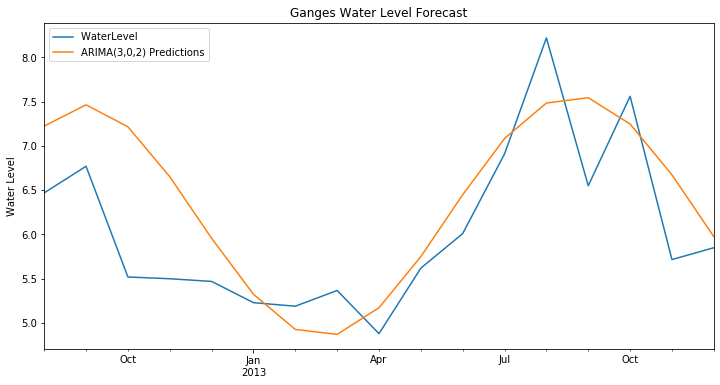

In [17]:
# Plot predictions against known values
title = 'Ganges Water Level Forecast'
ylabel='Water Level'
xlabel='' # we don't really need a label here

ax = test['WaterLevel '].plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
#ax.yaxis.set_major_formatter(formatter);

### Evaluate the Model

In [18]:
from sklearn.metrics import mean_squared_error

error = mean_squared_error(test['WaterLevel '], predictions)
print(f'ARIMA(3,0,2) MSE Error: {error:11.10}')

ARIMA(3,0,2) MSE Error: 0.5116933598


In [19]:
from statsmodels.tools.eval_measures import rmse

error = rmse(test['WaterLevel '], predictions)
print(f'ARIMA(3,0,2) RMSE Error: {error:11.10}')

ARIMA(3,0,2) RMSE Error: 0.7153274494


### Retrain the model on the full data, and forecast the future

In [20]:
model = ARIMA(df['WaterLevel '],order=(3,0,2))
results = model.fit()
fcast = results.predict(len(df),len(df)+11,typ='levels').rename('ARIMA(3,0,2) Forecast')

[Text(0, 0.5, 'Water Level'), Text(0.5, 0, '')]

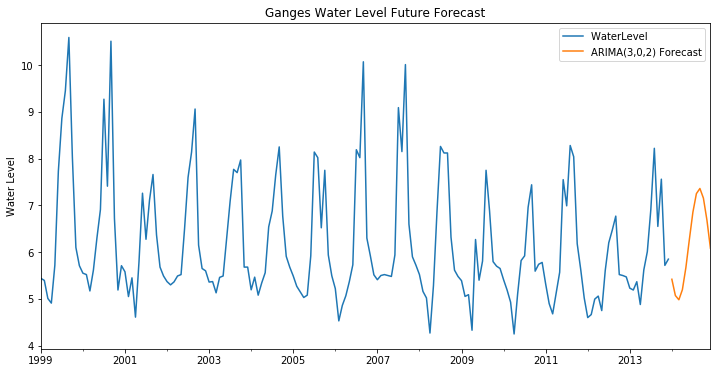

In [23]:
# Plot predictions against known values
title = 'Ganges Water Level Future Forecast'
ylabel='Water Level'
xlabel='' # we don't really need a label here

ax = df['WaterLevel '].plot(legend=True,figsize=(12,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
#ax.yaxis.set_major_formatter(formatter);

In [22]:
df.mean()

WaterLevel     6.171607
dtype: float64